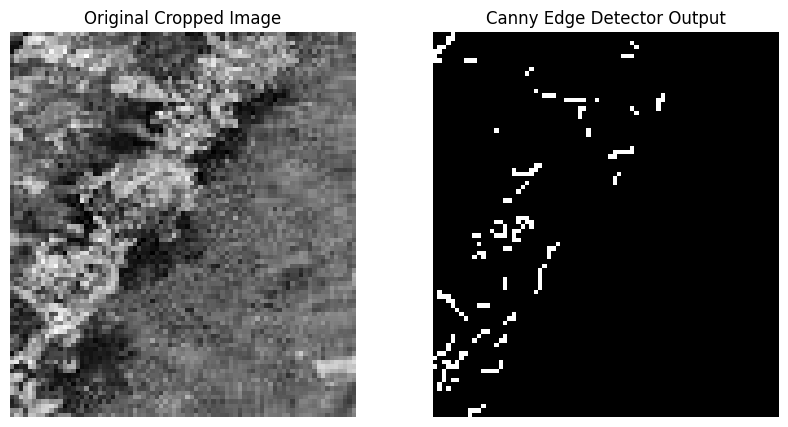

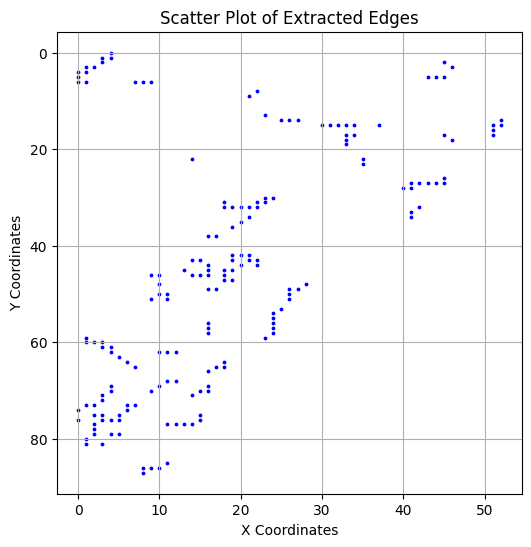

Estimated crop field angle (Least-Squares): -43.39 degrees


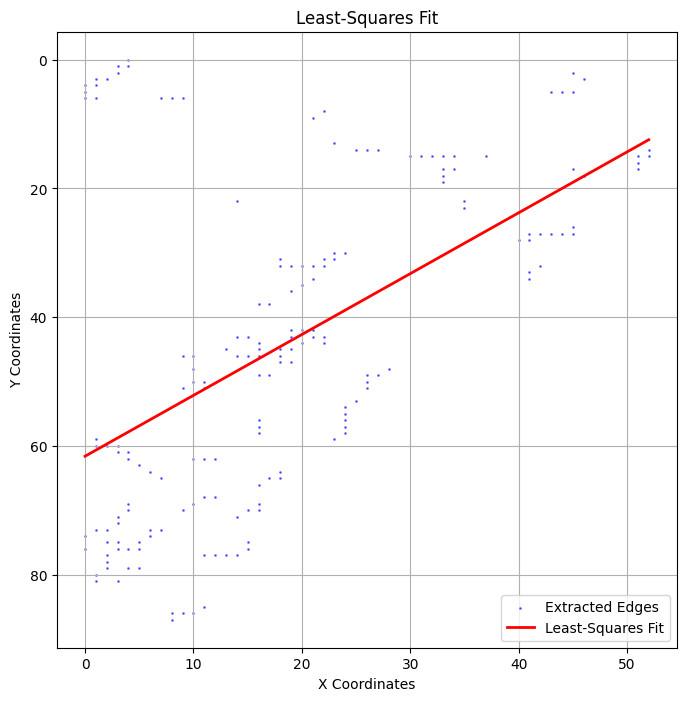

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('../Images/img3.jpg', 0)

assert img is not None

# Question 1
# Apply the Canny edge detector
edges = cv.Canny(img, 550, 690)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Cropped Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edge Detector Output')
plt.axis('off')

plt.show()

# Question 2
# Extract coordinates using NumPy
indices = np.where(edges != 0)

x = indices[1]
y = indices[0]

plt.figure(figsize=(6, 6))

plt.scatter(x, y, s=3, color='blue')

plt.gca().invert_yaxis()

plt.title('Scatter Plot of Extracted Edges')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.grid(True)

plt.show()

# Question 3
N = len(x)

sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)

m_ls = (N * sum_xy - sum_x * sum_y) / (N * sum_x2 - sum_x**2)
c_ls = (sum_y - m_ls * sum_x) / N

x_line = np.array([np.min(x), np.max(x)])
y_line_ls = m_ls * x_line + c_ls

# Question 4
angle_rad_ls = np.arctan(m_ls)
angle_deg_ls = np.degrees(angle_rad_ls)

print(f"Estimated crop field angle (Least-Squares): {angle_deg_ls:.2f} degrees")

plt.figure(figsize=(8, 8))

# Plot the extracted edge points (using alpha=0.5 makes them slightly see-through)
plt.scatter(x, y, s=1, color='blue', alpha=0.5, label='Extracted Edges')

# Plot the calculated Least-Squares line
plt.plot(x_line, y_line_ls, color='red', linewidth=2, label='Least-Squares Fit')

plt.gca().invert_yaxis()

plt.title('Least-Squares Fit')
plt.xlabel('X Coordinates')
plt.ylabel('Y Coordinates')
plt.legend()
plt.grid(True)

plt.show()